# Exploratory Data Analysis (EDA) of Heart Disease Data

In this notebook, I analyze a clinical Heart Disease dataset to uncover hidden patterns, counterintuitive relationships, and key risk factors associated with heart disease diagnosis. 

This project demonstrates data manipulation using `pandas` and visualizations using `matplotlib` to extract medical insights directly within a Jupyter environment.

**Main objectives and analyses covered in this notebook:**
1. **Data Inspection:** Loading and understanding the clinical features.
2. **Demographic Profiling:** Analyzing the relationship between a patient's age and their diagnosis rate.
3. **Correlation Analysis:** Generating a heatmap to identify the strongest mathematical predictors of heart disease.
4. **Distribution & Outliers:** Examining continuous variables (blood pressure, cholesterol, max heart rate) via boxplots.
5. **Categorical Deep Dive:** Uncovering counterintuitive clinical trends specifically related to Chest Pain types (`cp`).
6. **Multivariate Analysis:** Combining 4 dimensions (Age, Max HR, Diagnosis, and ST Depression) with physiological baselines to reveal complex clinical patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Age vs. Diagnosis
In this section, I want to see how age impacts the likelihood of heart disease. Instead of looking at individual ages, we will group the patients into 10-year "bins" (e.g., 30-40, 41-50) using `pd.cut()`.

In [4]:
# sorting patients' age into bins

bins = [20, 30, 40, 50, 60, 70, 80]
labels = ['20-30', '31-40', '41-50', '51-60', '61-70', '71-80']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

In [5]:
# total patients and sick patients per age group
age_stats = df.groupby('age_group', observed=False)['target'].agg(['count', 'sum']).reset_index()

print(age_stats)

  age_group  count  sum
0     20-30      4    4
1     31-40     64   41
2     41-50    247  166
3     51-60    438  204
4     61-70    252   94
5     71-80     20   17


In [6]:
# percentage of sick patients
age_stats['percent_sick'] = (age_stats['sum'] / age_stats['count']) * 100

print(age_stats)

  age_group  count  sum  percent_sick
0     20-30      4    4    100.000000
1     31-40     64   41     64.062500
2     41-50    247  166     67.206478
3     51-60    438  204     46.575342
4     61-70    252   94     37.301587
5     71-80     20   17     85.000000


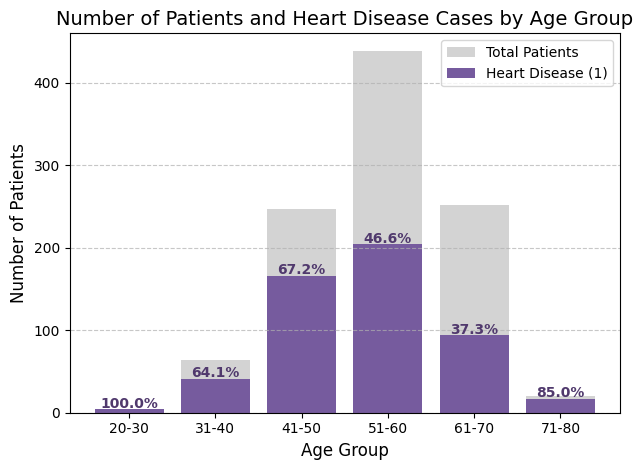

In [7]:
# plot
plt.bar(age_stats['age_group'], age_stats['count'], color='lightgray', label='Total Patients')
plt.bar(age_stats['age_group'], age_stats['sum'], color='#765b9e', label='Heart Disease (1)')

plt.title('Number of Patients and Heart Disease Cases by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# adding percentage
for i in range(len(age_stats)):
    percent = age_stats['percent_sick'].iloc[i]
    if pd.notna(percent): 
        plt.text(i, age_stats['sum'].iloc[i] + 2, f'{percent:.1f}%', ha='center', color='#50396d', fontweight='bold')

plt.tight_layout()
plt.show()

Looking at the generated bar chart, we can observe a pattern. The highest volume of patients in this dataset falls into the **51-60 age group**, but their diagnosis rate is 46.6%. However, the **41-50 age group** shows a strikingly high positive diagnosis rate of **67.2%**. We can also see that while the sample size for the oldest group (71-80) is very small, almost all of them (85.0%) have a positive diagnosis.

The youngest group (**20-30 years old**) shows a 100.0% diagnosis rate. However, there are only 4 patients in this bracket. Because this sample size is so small, this is a statistical outlier rather than a general medical rule. These young patients were likely included in the dataset precisely because they already had severe, unusual symptoms that required extensive testing.

### Correlation Matrix
I will calculate the Pearson correlation coefficient between all numerical features. This tells us which medical indicators move together and, most importantly, which ones are strongly tied to the `target` (the diagnosis).

In [8]:
# drop age group
df_numeric = df.drop(columns=['age_group'])

In [9]:
corr_matrix = df_numeric.corr()

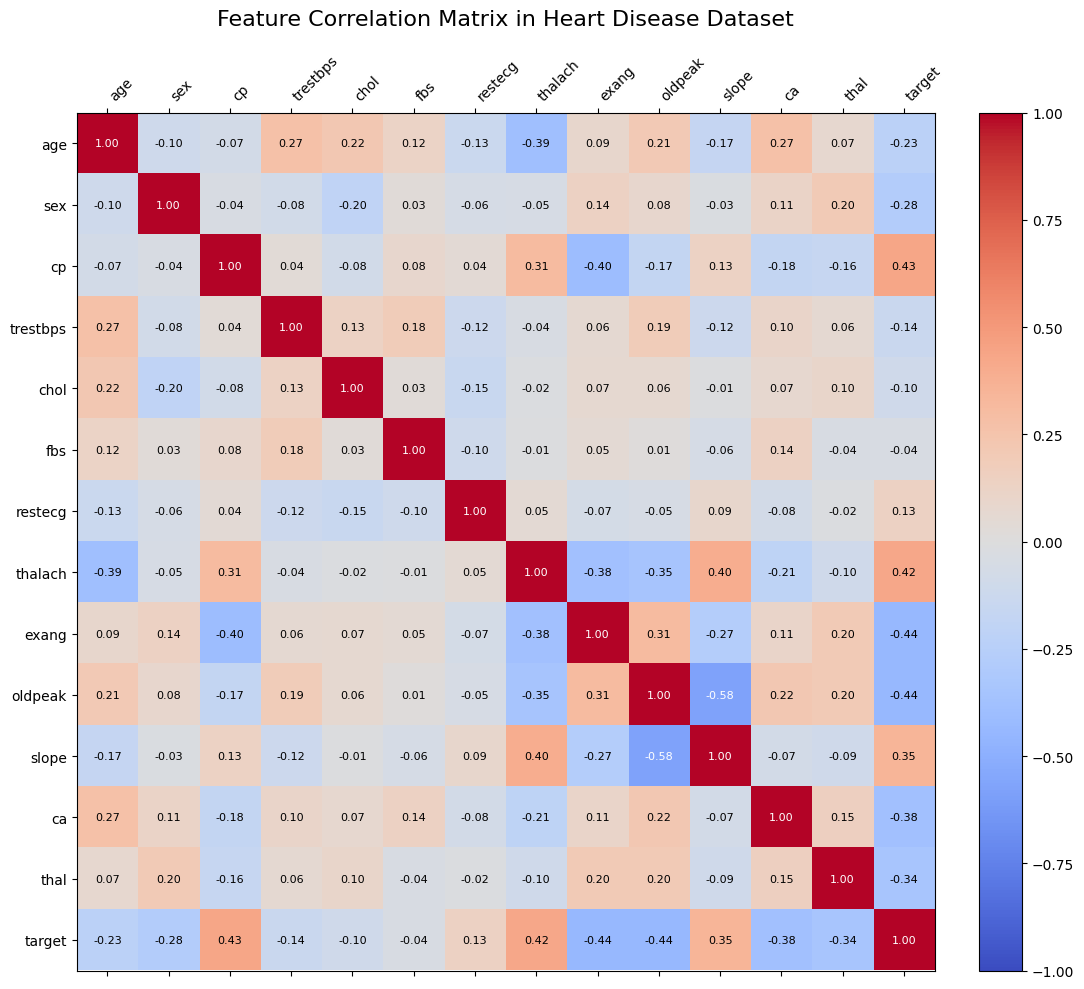

In [10]:
# visualisation
fig, ax = plt.subplots(figsize=(12, 10))

# red is positive, blue is negative
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

fig.colorbar(cax, fraction=0.046, pad=0.04)

columns = corr_matrix.columns
ax.set_xticks(np.arange(len(columns)))
ax.set_yticks(np.arange(len(columns)))
ax.set_xticklabels(columns, rotation=45, ha='left', fontsize=10)
ax.set_yticklabels(columns, fontsize=10)

# add correlation values inside each cell
for i in range(len(columns)):
    for j in range(len(columns)):
        value = corr_matrix.iloc[i, j]
        text_color = "white" if abs(value) > 0.5 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)

plt.title('Feature Correlation Matrix in Heart Disease Dataset', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

When reading correlation metrics, the **absolute value** (distance from zero) determines the strength of the relationship. This means a deep blue (-0.44) is a mathematically stronger predictor than a deep red (0.43).

* **The Strongest Overall Predictors (Negative):** Exercise-induced angina (`exang`, **-0.44**) and ST depression (`oldpeak`, **-0.44**) show the strongest correlation with the target. A negative value indicates an inverse relationship. In the context of this dataset, it means that the *absence* of exercise-induced angina or *lower* values of ST depression are actually the strongest indicators of a positive diagnosis (`target=1`).
* **The Strongest Positive Predictors:** Chest pain type (`cp`, **0.43**) and maximum heart rate achieved (`thalach`, **0.42**). The relationship is direct: specific types of chest pain and higher maximum heart rates increase the likelihood of heart disease.

### Continuous Variables Distribution & Outliers (Boxplots)
Now I will examine the distribution of three key continuous clinical variables: Resting Blood Pressure (`trestbps`), Cholesterol (`chol`), and Maximum Heart Rate Achieved (`thalach`).

I will split the data by our `target` variable to visually compare healthy patients (0) against those diagnosed with heart disease (1).

C:\Users\Sprzetowo\AppData\Local\Temp\ipykernel_6468\1085051462.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot([healthy_data, disease_data],
C:\Users\Sprzetowo\AppData\Local\Temp\ipykernel_6468\1085051462.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot([healthy_data, disease_data],
C:\Users\Sprzetowo\AppData\Local\Temp\ipykernel_6468\1085051462.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot([healthy_data, disease_data],


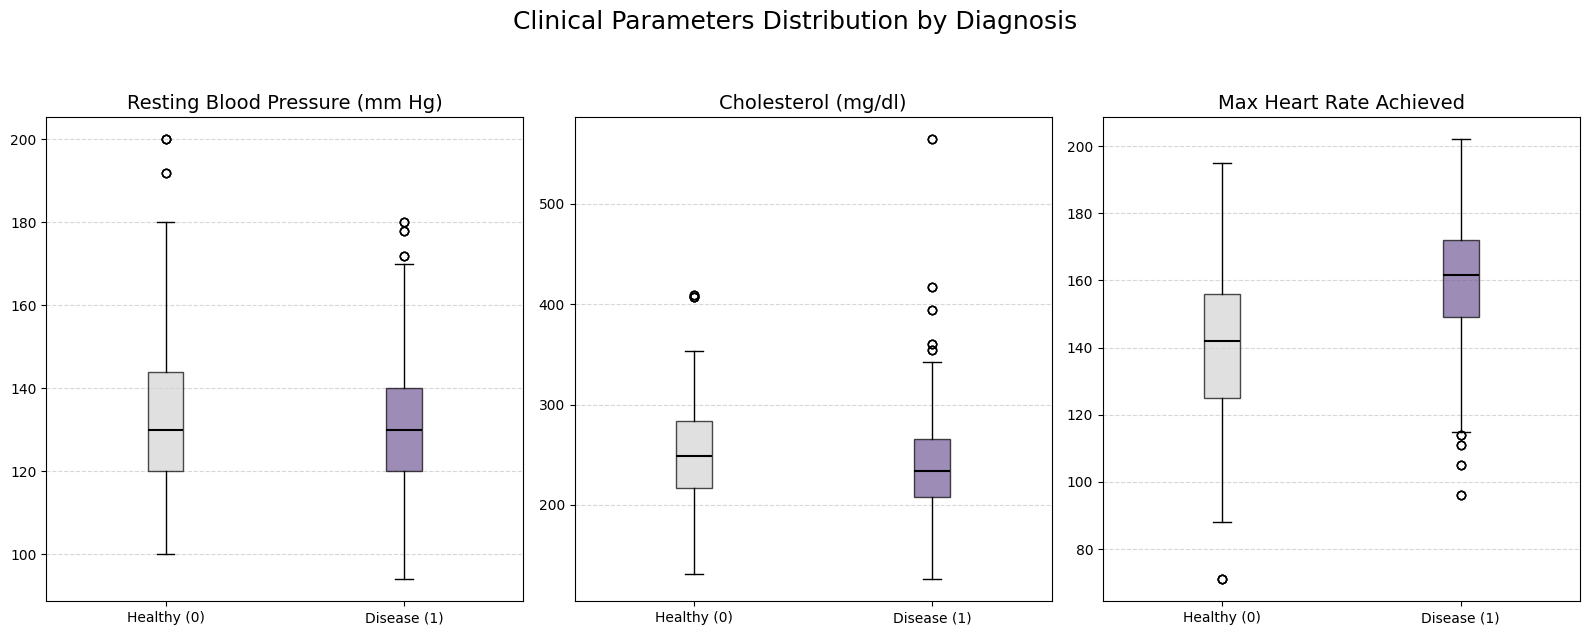

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

features = ['trestbps', 'chol', 'thalach']
titles = ['Resting Blood Pressure (mm Hg)', 'Cholesterol (mg/dl)', 'Max Heart Rate Achieved']

for i, feature in enumerate(features):
    healthy_data = df[df['target'] == 0][feature]
    disease_data = df[df['target'] == 1][feature]

    box = axes[i].boxplot([healthy_data, disease_data], 
                          labels=['Healthy (0)', 'Disease (1)'],
                          patch_artist=True,
                          medianprops={'color': 'black', 'linewidth': 1.5})

    colors = ['lightgray', '#745b97']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[i].set_title(titles[i], fontsize=14)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Clinical Parameters Distribution by Diagnosis', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [12]:
features = ['trestbps', 'chol', 'thalach']
medians_df = df.groupby('target')[features].median()

medians_df.index = ['Healthy (0)', 'Disease (1)']

medians_df.columns = ['Resting Blood Pressure', 'Cholesterol', 'Max Heart Rate']

display(medians_df)

,Resting Blood Pressure,Cholesterol,Max Heart Rate
Healthy (0),130.0,249.0,142.0
Disease (1),130.0,234.0,161.5


Based on the generated visualizations, we can observe the actual spread of the continuous clinical data and how it relates to the diagnosis:

* **Resting Blood Pressure (`trestbps`):** The distributions for both groups are nearly identical, with the medians sitting right around 130 mm Hg for both healthy and diagnosed patients. This visually confirms that resting blood pressure alone is not a strong differentiator in this specific dataset.
* **Cholesterol (`chol`):** Surprisingly, the median cholesterol level is slightly *lower* for the disease group compared to the healthy group. Both groups share a similar interquartile range (the box size) and feature significant outliers—including one extreme case in the disease group nearing 600 mg/dl. Because the distributions overlap so heavily, cholesterol is a weak standalone predictor here.
* **Max Heart Rate Achieved (`thalach`):** This is the only feature among the three that shows a clear separation. The entire "box" (representing the middle 50% of the patients) and the median are noticeably higher for the disease group (median ~160) compared to the healthy group (median ~140). This perfectly aligns with our correlation matrix: higher maximum heart rates achieved during the test are strongly associated with a positive diagnosis.

### Chest Pain Type (`cp`)
Our correlation matrix revealed that Chest Pain Type (`cp`) is the strongest positive predictor of heart disease in this dataset. Let's break this feature down to understand exactly which types of pain are most dangerous.

According to the dataset documentation, the `cp` feature has 4 categories:
* **0:** chest pain related to decreased blood supply to the heart
* **1:** chest pain not related to the heart
* **2:** typically esophageal spasms - non heart related
* **3:** chest pain not showing signs of disease

In [14]:
# group data
cp_stats = df.groupby('cp')['target'].agg(['count', 'sum']).reset_index()
cp_stats.columns = ['cp', 'Total', 'Disease']

print(cp_stats)

   cp  Total  Disease
0   0    497      122
1   1    167      134
2   2    284      219
3   3     77       51


In [15]:
# sick and healthy patients
cp_stats['Healthy'] = cp_stats['Total'] - cp_stats['Disease']
cp_stats['Disease_Percentage'] = (cp_stats['Disease'] / cp_stats['Total']) * 100

print(cp_stats)

   cp  Total  Disease  Healthy  Disease_Percentage
0   0    497      122      375           24.547284
1   1    167      134       33           80.239521
2   2    284      219       65           77.112676
3   3     77       51       26           66.233766


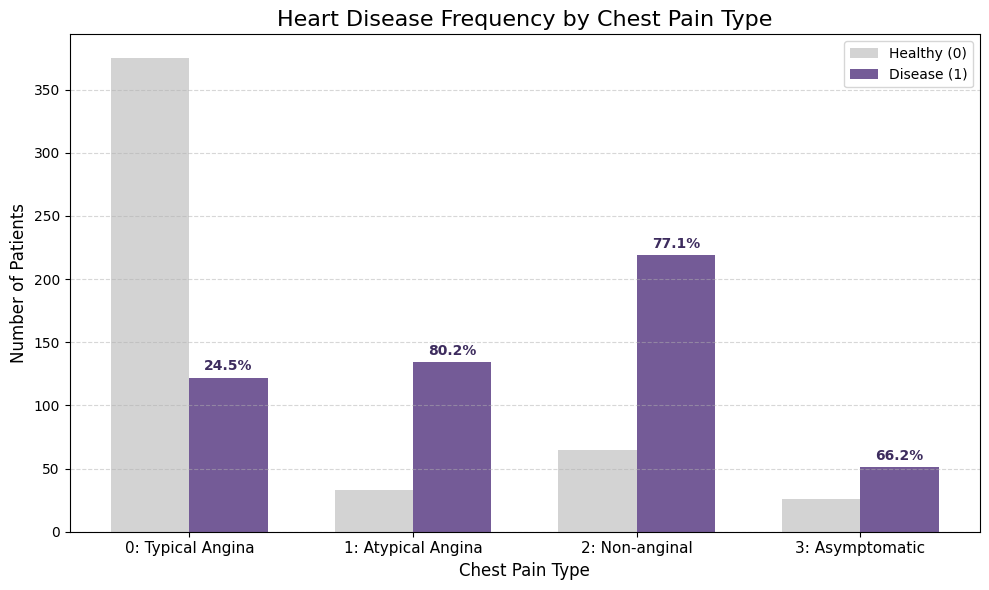

In [16]:
cp_labels = ['0: Typical Angina', '1: Atypical Angina', '2: Non-anginal', '3: Asymptomatic']

# bar chart
x = np.arange(len(cp_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plot healthy (gray) and disease (purple)
rects1 = ax.bar(x - width/2, cp_stats['Healthy'], width, label='Healthy (0)', color='lightgray')
rects2 = ax.bar(x + width/2, cp_stats['Disease'], width, label='Disease (1)', color='#745b97')

# Formatting the chart
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_xlabel('Chest Pain Type', fontsize=12)
ax.set_title('Heart Disease Frequency by Chest Pain Type', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(cp_labels, fontsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# percentage labels
for i in range(len(cp_stats)):
    percent = cp_stats['Disease_Percentage'].iloc[i]
    height = cp_stats['Disease'].iloc[i]
    ax.annotate(f'{percent:.1f}%',
                xy=(x[i] + width/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                color='#3d2c5e', fontweight='bold')

plt.tight_layout()
plt.show()

* Human intuition might assume that "Typical Angina" (Type 0) is the most dangerous symptom. However, the data proves otherwise. While it is the most common complaint overall, it has the *lowest* positive diagnosis rate. Only **24.5%** of patients with Type 0 pain actually have heart disease in this dataset (the vast majority are healthy).
* Patients experiencing "Atypical Angina" (Type 1) and "Non-anginal pain" (Type 2) are at the highest risk. Their diagnosis rates are staggeringly high at **80.2%** and **77.1%**, respectively. 
* Patients categorized as "Asymptomatic" (Type 3) show a high disease frequency (**66.2%**), though the overall sample size for this group is the smallest.

### Age vs Max Heart Rate
To truly understand the interactions between features, we need to look beyond two dimensions. In this section, we will analyze four variables simultaneously: `age`, `thalach` (Max Heart Rate), `target` (Diagnosis), and `oldpeak` (ST depression).

In cardiology, a patient's estimated theoretical maximum heart rate is calculated using the formula:
**`Max HR = 220 - Age`**

By plotting this theoretical baseline alongside our patient data, we can see if the clinical test results approach or exceed normal physiological limits, and how that relates to their diagnosis.

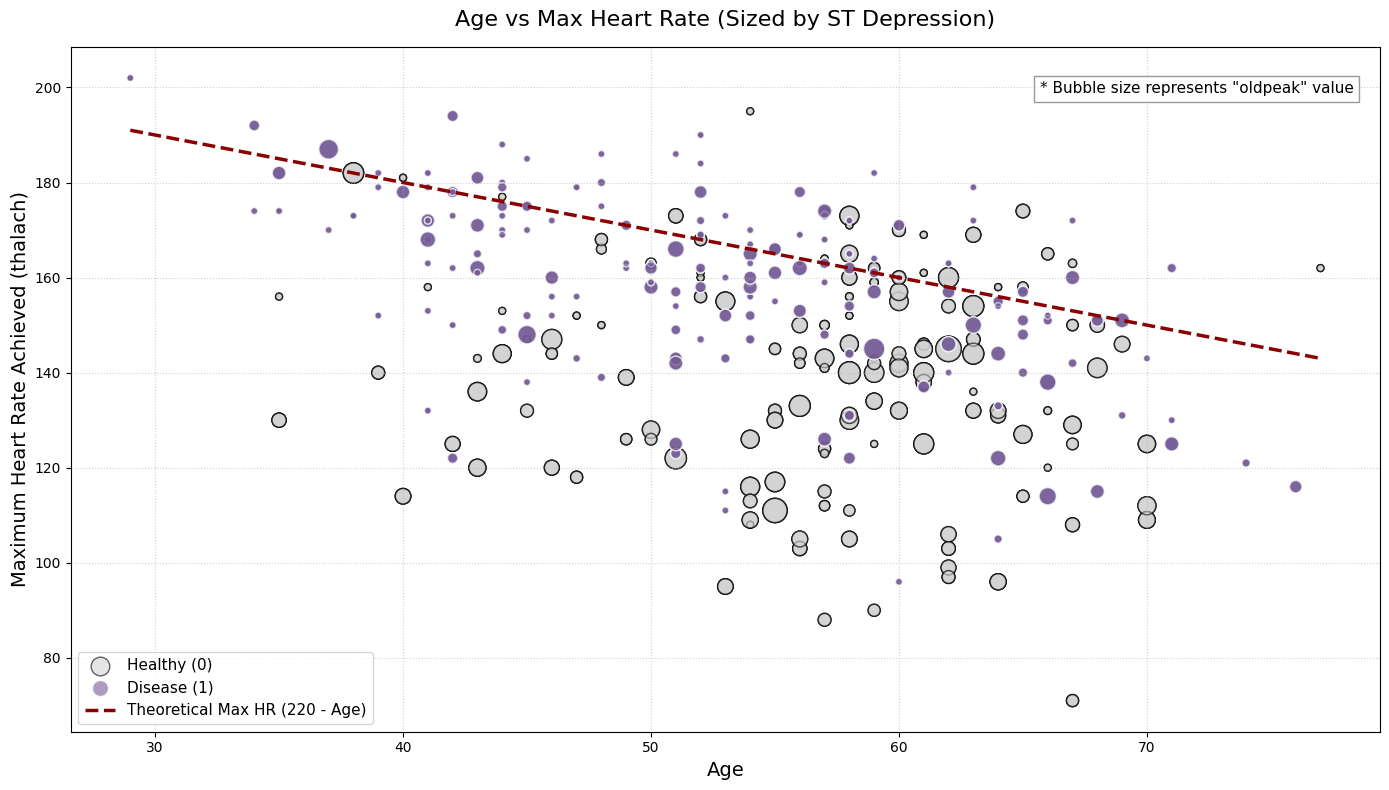

In [18]:
fig, ax = plt.subplots(figsize=(14, 8))

# seperate
healthy = df[df['target'] == 0]
disease = df[df['target'] == 1]

# healthy
ax.scatter(healthy['age'], healthy['thalach'], 
           c='lightgray', s=(healthy['oldpeak'] + 0.5) * 50, 
           alpha=0.6, edgecolors='black', label='Healthy (0)')

# disease
ax.scatter(disease['age'], disease['thalach'], 
           c='#745b97', s=(disease['oldpeak'] + 0.5) * 50, 
           alpha=0.6, edgecolors='white', label='Disease (1)')

# medical chart
x_ages = np.linspace(df['age'].min(), df['age'].max(), 100)
y_max_hr = 220 - x_ages
ax.plot(x_ages, y_max_hr, color='darkred', linestyle='--', linewidth=2.5, 
        label='Theoretical Max HR (220 - Age)')

# Formatting 
ax.set_title('Age vs Max Heart Rate (Sized by ST Depression)', fontsize=16, pad=15)
ax.set_xlabel('Age', fontsize=14)
ax.set_ylabel('Maximum Heart Rate Achieved (thalach)', fontsize=14)
ax.legend(fontsize=11, loc='lower left')
ax.grid(True, linestyle=':', alpha=0.6)

# text
ax.text(0.98, 0.95, '* Bubble size represents "oldpeak" value', 
        transform=ax.transAxes, ha='right', va='top', 
        fontsize=11, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

This complex visualization allows us to see how four different dimensions interact simultaneously, revealing patterns that simple correlations cannot fully explain:

1. **The Age vs. Max HR Baseline (The Red Line):** As expected physiologically, the maximum heart rate achieved trends downward as age increases. The red dashed line represents the theoretical maximum heart rate (`220 - age`). We can see most patients safely stay below this limit.
2. **The Heart Rate Anomaly (Y-Axis Clustering):** Notice the distribution of colors along the Y-axis. The purple dots (Disease) generally cluster *higher* up than the gray bubbles (Healthy). Many healthy patients have maximum heart rates dropping below 140 or even 120, while the disease group consistently pushes closer to their theoretical limit. This visually confirms that a higher max heart rate in this specific dataset is a strong red flag.
3. **The 'Oldpeak' Impact (Bubble Size):** Look at the physical size of the data points. The massive bubbles (representing high `oldpeak` values / ST depression) are overwhelmingly gray (Healthy). Conversely, the purple disease points are predominantly small dots (low `oldpeak` values). This perfectly visualizes the strong *negative* correlation we discovered earlier: a lower `oldpeak` value combined with a high heart rate is the most dangerous clinical combination in this sample.